In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

In [149]:
nav = pd.read_csv("../data/processed/nav_history.csv")
performance = pd.read_csv("../data/processed/scheme_performance.csv")
benchmark = pd.read_csv("../data/processed/benchmark_indices.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [150]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print(nav.head())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210


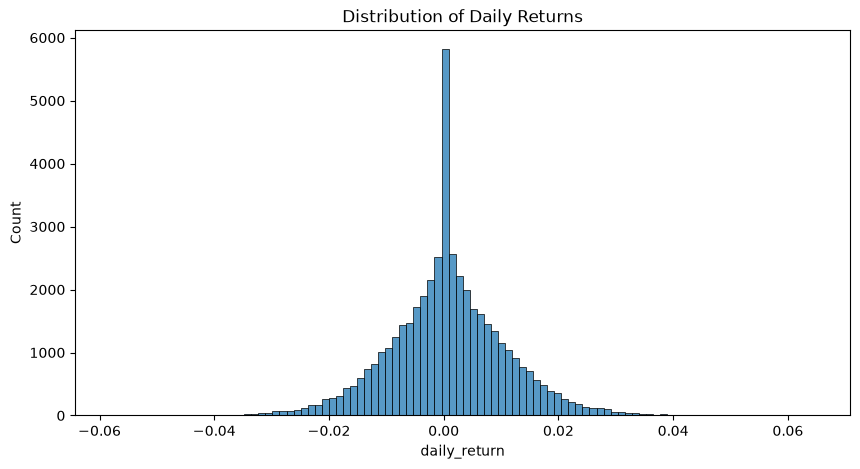

In [151]:
plt.figure(figsize=(10,5))
sns.histplot(nav["daily_return"].dropna(), bins=100)
plt.title("Distribution of Daily Returns")
plt.show()

In [152]:
def cagr(start, end, years):
    return (end / start) ** (1 / years) - 1

rows = []

for code, df in nav.groupby("amfi_code"):

    df = df.sort_values("date")

    start = df["nav"].iloc[0]
    end = df["nav"].iloc[-1]

    rows.append({
        "amfi_code": code,
        "CAGR": cagr(start, end, 5)
    })

cagr_df = pd.DataFrame(rows)

print(cagr_df.head())

   amfi_code      CAGR
0     100016  0.023168
1     100025  0.039127
2     100033  0.260741
3     101206  0.204427
4     101207  0.069533


In [153]:
RF = 0.065

rows = []

for code, df in nav.groupby("amfi_code"):

    r = df["daily_return"].dropna()

    sharpe = (
        (r.mean() * 252 - RF)
        /
        (r.std() * np.sqrt(252))
    )

    rows.append([code, sharpe])

sharpe_df = pd.DataFrame(
    rows,
    columns=["amfi_code", "Sharpe"]
)

sharpe_df.sort_values(
    "Sharpe",
    ascending=False,
    inplace=True
)

print(sharpe_df.head())

    amfi_code    Sharpe
34     148567  1.448291
30     120843  1.306744
36     148569  1.234930
19     119551  1.208267
25     120505  1.180101


In [154]:
rows = []

for code, df in nav.groupby("amfi_code"):

    r = df["daily_return"].dropna()

    downside = r[r < 0]

    downside_std = downside.std()

    sortino = (
        (r.mean() * 252 - RF)
        /
        (downside_std * np.sqrt(252))
    )

    rows.append([code, sortino])

sortino_df = pd.DataFrame(
    rows,
    columns=["amfi_code", "Sortino"]
)

In [155]:

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty = benchmark[benchmark["index_name"] == "NIFTY100"].copy()
nifty = nifty.sort_values("date")
nifty["benchmark_return"] = nifty["close_value"].pct_change()

rows = []

for code, fund in nav.groupby("amfi_code"):

    fund = fund.sort_values("date")

    temp = pd.merge(
        fund,
        nifty[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    temp = temp.dropna(subset=["daily_return", "benchmark_return"])

    if len(temp) < 30:
        print(f"Skipping {code} - only {len(temp)} observations")
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        temp["benchmark_return"],
        temp["daily_return"]
    )

    rows.append({
        "amfi_code": code,
        "Alpha": intercept * 252,
        "Beta": slope
    })

alpha_beta = pd.DataFrame(rows)

print(alpha_beta.head())
print(alpha_beta.shape)

alpha_beta.to_csv("../reports/alpha_beta.csv", index=False)

   amfi_code     Alpha      Beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289
(40, 3)


In [156]:
rows = []

for code, df in nav.groupby("amfi_code"):

    df = df.copy()

    df["running_max"] = df["nav"].cummax()

    df["drawdown"] = (
        df["nav"]
        /
        df["running_max"]
        - 1
    )

    rows.append([
        code,
        df["drawdown"].min()
    ])

drawdown = pd.DataFrame(
    rows,
    columns=["amfi_code", "Max_Drawdown"]
)

In [157]:
print(score.columns.tolist())

print(sharpe_df.columns.tolist())

print(alpha_beta.columns.tolist())

print(alpha_beta.shape)

print(benchmark["index_name"].unique())

['amfi_code', 'scheme_name', 'return_3yr_pct', 'expense_ratio_pct', 'Sharpe', 'Alpha', 'Beta', 'Max_Drawdown', 'ReturnRank', 'SharpeRank', 'AlphaRank', 'ExpenseRank', 'DrawdownRank', 'FundScore']
['amfi_code', 'Sharpe']
['amfi_code', 'Alpha', 'Beta']
(40, 3)
<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [159]:
temp = pd.merge(
    df,
    nifty[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

print(temp.head())
print(code,len(temp))

   amfi_code       date      nav  daily_return  running_max  drawdown  \
0     149324 2022-01-03  81.6814           NaN      81.6814  0.000000   
1     149324 2022-01-04  80.8239     -0.010498      81.6814 -0.010498   
2     149324 2022-01-05  80.6143     -0.002593      81.6814 -0.013064   
3     149324 2022-01-06  79.9386     -0.008382      81.6814 -0.021337   
4     149324 2022-01-07  80.8723      0.011680      81.6814 -0.009906   

   benchmark_return  
0               NaN  
1         -0.013540  
2          0.004003  
3         -0.002935  
4          0.006150  
149324 1150


In [160]:
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [161]:
nifty = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty["benchmark_return"] = nifty["close_value"].pct_change()

rows = []

for code, df in nav.groupby("amfi_code"):

    temp = pd.merge(
        df,
        nifty[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    temp = temp.dropna()

    if len(temp) >= 30:

        slope, intercept, r, p, stderr = linregress(
            temp["benchmark_return"],
            temp["daily_return"]
        )

        rows.append({
            "amfi_code": code,
            "Alpha": intercept * 252,
            "Beta": slope
        })

alpha_beta = pd.DataFrame(rows)

print(alpha_beta.head())
print(alpha_beta.shape)

   amfi_code     Alpha      Beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289
(40, 3)


In [162]:
score = performance[
    [
        "amfi_code",
        "scheme_name",
        "return_3yr_pct",
        "expense_ratio_pct"
    ]
]

score = score.merge(
    sharpe_df,
    on="amfi_code"
)

score = score.merge(
    alpha_beta,
    on="amfi_code"
)

score = score.merge(
    drawdown,
    on="amfi_code"
)

In [163]:
score["ReturnRank"] = score["return_3yr_pct"].rank()
score["SharpeRank"] = score["Sharpe"].rank()
score["AlphaRank"] = score["Alpha"].rank()

score["ExpenseRank"] = (
    score["expense_ratio_pct"]
    .rank(ascending=False)
)

score["DrawdownRank"] = (
    score["Max_Drawdown"]
    .rank(ascending=False)
)


In [164]:
score["FundScore"] = (
    score["ReturnRank"] * 0.30
    + score["SharpeRank"] * 0.25
    + score["AlphaRank"] * 0.20
    + score["ExpenseRank"] * 0.15
    + score["DrawdownRank"] * 0.10
)

score = score.sort_values(
    "FundScore",
    ascending=False
)

score.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)


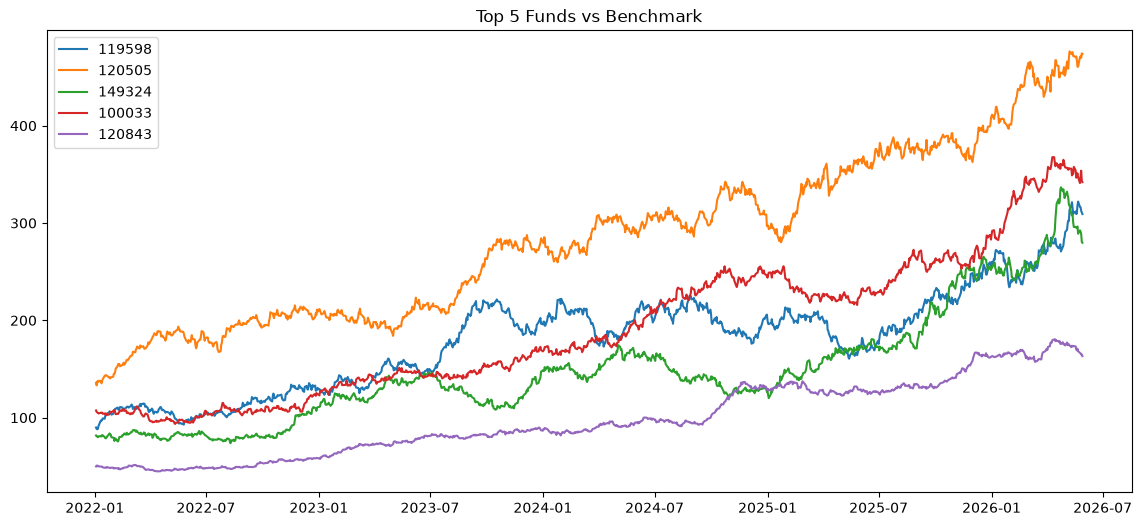

In [165]:
top5 = score.head()["amfi_code"]

plt.figure(figsize=(14,6))

for code in top5:

    df = nav[
        nav["amfi_code"] == code
    ]

    plt.plot(
        df["date"],
        df["nav"],
        label=str(code)
    )

plt.legend()

plt.title(
    "Top 5 Funds vs Benchmark"
)

plt.savefig(
    "../charts/benchmark_comparison.png"
)

plt.show()